In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import cv2

from collections import Counter
from pathlib import Path

In [3]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [18]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data/raw"
CSV_PATH = DATA_DIR / "Data_Entry_2017.csv"

In [ ]:

os.listdir(DATA_DIR)

['.gitignore',
 'ARXIV_V5_CHESTXRAY.pdf',
 'BBox_List_2017.csv',
 'Data_Entry_2017.csv',
 'FAQ_CHESTXRAY.pdf',
 'images_001',
 'images_002',
 'images_003',
 'images_004',
 'images_005',
 'images_006',
 'images_007',
 'images_008',
 'images_009',
 'images_010',
 'images_011',
 'images_012',
 'LOG_CHESTXRAY.pdf',
 'README_CHESTXRAY.pdf',
 'test_list.txt',
 'train_val_list.txt']

# Toolkit and Utilities

In [22]:
FIG_PATH = PROJECT_ROOT / "reports/figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_name, folder=None, tight_layout=True, fig_extension="png", dpi=300):

    if folder:
        path = FIG_PATH / folder
        path.mkdir(exist_ok=True)
        filepath = path / f"{fig_name}.png"
    else:
        filepath = FIG_PATH / f"{fig_name}.png"
    
    if tight_layout:
        plt.tight_layout()
        
    plt.savefig(filepath, format=fig_extension, dpi=dpi)

In [23]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[column] < lower) | (df[column] > upper)

    return mask, lower, upper

In [24]:
def univ_num_explore(data, num_col, fig_title="", figsize=(10, 4)):
    """to be written soon"""

    print(f"Analysis for '{num_col}'")
    print("-" * 40)
    
    # Summary statistics
    print(data[num_col].describe())
    print("Missing:", df[num_col].isna().sum())
    
    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Histogram with KDE
    sns.histplot(data=data, x=num_col, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {num_col}")
    
    # Boxplot
    sns.boxplot(data=data, x=num_col, ax=axes[1])
    axes[1].set_title(f"Boxplot of {num_col}")
    
    if fig_title == "":
        fig_title = f"{num_col.lower().replace(" ", "_")}_distribution"
        
    save_fig(fig_title, "univariate")
    
    plt.show()

In [25]:
def univ_cat_explore(data, cat_col, fig_title="", top_n=5, figsize=(6, 4)):
    """to be written soon"""
    
    # Value Counts
    print(f"Value counts for {cat_col}:")
    print(data[cat_col].value_counts()) # you can pass Normalize=True to show percentage
    print("\n")
    
    counts = data[cat_col].value_counts()
    perc = data[cat_col].value_counts(normalize=True) * 100

    summary = pd.concat([counts, perc], axis=1)
    summary.columns = ["Count", "Percent"]

    print(summary)
    print("\n")
    # Top Categories (Most frequent)
    top_categories = data[cat_col].value_counts().head(top_n)

   # Pie Chart (for only small No. of categories like 4)
    # if data[cat_col].nunique() <= 4:
    #     data[cat_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    #     plt.ylabel('')  # Hide y-label for better visualization
    #     plt.title(f"Distribution of {cat_col}")
    #     plt.show()

   # Bar Plot (for top n > 4 unique values)
    plt.figure(figsize=figsize)
    sns.countplot(data=data, x=cat_col, order=top_categories.index)
    # plt.title(f'Bar Plot of Top {top_n} Categories in {cat_col}')
    plt.title(f'Bar Plot of {cat_col}')
    plt.xticks(rotation=45)

    if fig_title == "":
        fig_title = f"{cat_col.lower().replace(" ", "_")}_distribution"
        
    save_fig(fig_title, "univariate")
    plt.show()
    

In [26]:
def num_vs_num(df, num_col1, num_col2):
    # Corelation
    print(f'Linear Correlation between {num_col1} and {num_col2} : ', df[num_col1].corr(df[num_col2]).round(2))
    
    # Reg Plot
    plt.figure(figsize=(6, 4))
    sns.regplot(x=df[num_col1], y=df[num_col2], scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.xlabel(num_col1)
    plt.ylabel(num_col2)
    plt.title(f"Relationship between {num_col1} and {num_col2}")
    plt.show()

    
def num_vs_cat(df, num_col, cat_col):
    # Box Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[cat_col], y=df[num_col], hue= df[cat_col], palette="muted")
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.title(f"Distribution of {num_col} across {cat_col}")
    plt.xticks(rotation=45)
    plt.show()

    # You can make bar plot like num_vs_binary function

def num_vs_binary(df, num_col, binary_col):
    
    # Create the bar plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=binary_col, y=num_col, data=df, palette="pastel", errorbar=None, hue = binary_col)
    plt.title(f"Bar Plot: {num_col} vs {binary_col}")
    plt.xlabel(binary_col)
    plt.ylabel(f"Mean of {num_col}")
    plt.show

def cat_vs_binary(df, cat_col, binary_col):

    # Create the figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Adjust size as needed
    
    # Count plot: Count of each category in cat_col, split by binary_col
    sns.countplot(x=cat_col, hue=binary_col, data=df, palette="pastel", ax=axes[0])
    axes[0].set_title(f"Count Plot: {cat_col} vs {binary_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Count")
    axes[0].legend(title=binary_col, loc='upper right')
    
    # Group by categorical column and calculate the mean of binary column
    mean_data = df.groupby(cat_col)[binary_col].mean().reset_index()
    
    # Bar plot: Mean of binary_col for each category in cat_col
    sns.barplot(x=cat_col, y=binary_col, data=mean_data, palette="Set2", ax=axes[1], hue= cat_col)
    axes[1].set_title(f"Mean of {binary_col} by {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(f"Mean of {binary_col}")

    # Show the figure
    plt.tight_layout()
    plt.show()

# Data Loading

In [27]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")

df.head()

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


# Data Inspection

In [28]:
df.columns.to_list()

['Image Index',
 'Finding Labels',
 'Follow-up #',
 'Patient ID',
 'Patient Age',
 'Patient Gender',
 'View Position',
 'OriginalImage[Width',
 'Height]',
 'OriginalImagePixelSpacing[x',
 'y]',
 'Unnamed: 11']

In [29]:
columns_to_keep = [
 'Image Index',
 'Finding Labels',
 'Follow-up #',
 'Patient ID',
 'Patient Age',
 'Patient Gender',
 'View Position'
]

# Keeping only relevant columns
df = df[columns_to_keep]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   Image Index     112120 non-null  str  
 1   Finding Labels  112120 non-null  str  
 2   Follow-up #     112120 non-null  int64
 3   Patient ID      112120 non-null  int64
 4   Patient Age     112120 non-null  int64
 5   Patient Gender  112120 non-null  str  
 6   View Position   112120 non-null  str  
dtypes: int64(3), str(4)
memory usage: 6.0 MB


In [30]:
def quick_profile(df):
    print("\nRows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("\nMissing values:")
    print(df.isna().sum())
    
    print("\nDuplicate rows:", df.duplicated().sum())
    
    print("\nUnique values per column:")
    print(df.nunique())

In [31]:
# Dataset Overview
nunique_patient = df["Patient ID"].nunique()
print("Unique patients: {}".format(nunique_patient))
print("Images per patient: {}".format(len(df)/nunique_patient))

quick_profile(df)

Unique patients: 30805
Images per patient: 3.639668884921279

Rows: 112120
Columns: 7

Missing values:
Image Index       0
Finding Labels    0
Follow-up #       0
Patient ID        0
Patient Age       0
Patient Gender    0
View Position     0
dtype: int64

Duplicate rows: 0

Unique values per column:
Image Index       112120
Finding Labels       836
Follow-up #          184
Patient ID         30805
Patient Age          107
Patient Gender         2
View Position          2
dtype: int64


# Univariate Analysis

Analysis for 'Patient Age'
----------------------------------------
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64
Missing: 0


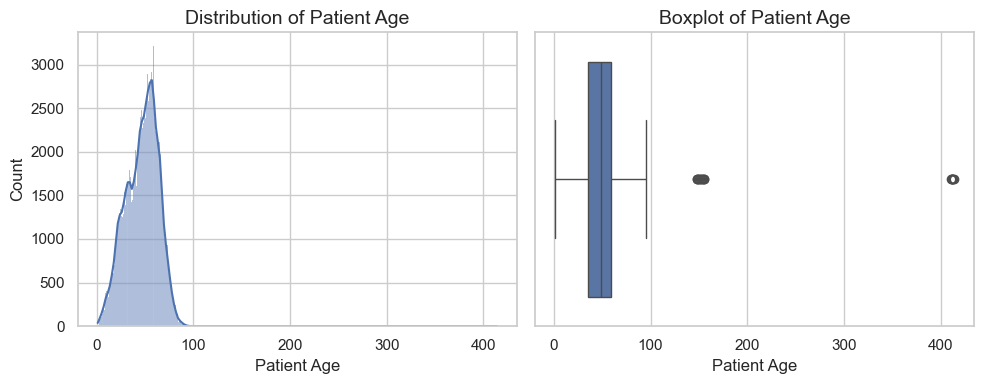

In [32]:
univ_num_explore(df, "Patient Age")

In [33]:
# Age diagnostics
print("Age > 100:", (df["Patient Age"] > 100).sum())
print("Age > 90:", (df["Patient Age"] > 90).sum())
print("Age > 80:", (df["Patient Age"] > 80).sum())

print("\nTop extreme ages:")
print(df["Patient Age"].sort_values(ascending=False).head(20))

print("\nAge distribution bins:")
print(pd.cut(df["Patient Age"], bins=[0,20,40,60,80,100,200,500]).value_counts().sort_index())

print("\nUnique extreme ages:")
print(sorted(df[df["Patient Age"] > 100]["Patient Age"].unique()))

Age > 100: 16
Age > 90: 51
Age > 80: 897

Top extreme ages:
46965     414
86264     413
91369     412
85404     412
20852     412
84810     411
101194    155
104590    155
98495     154
95794     153
74884     152
78795     151
58650     150
62929     149
48284     148
55742     148
58464      95
578        94
74733      94
74737      94
Name: Patient Age, dtype: int64

Age distribution bins:
Patient Age
(0, 20]        7812
(20, 40]      30143
(40, 60]      49502
(60, 80]      23766
(80, 100]       881
(100, 200]       10
(200, 500]        6
Name: count, dtype: int64

Unique extreme ages:
[np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154), np.int64(155), np.int64(411), np.int64(412), np.int64(413), np.int64(414)]


Analysis for 'Patient Age'
----------------------------------------
count    112104.000000
mean         46.872574
std          16.598152
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: Patient Age, dtype: float64
Missing: 0


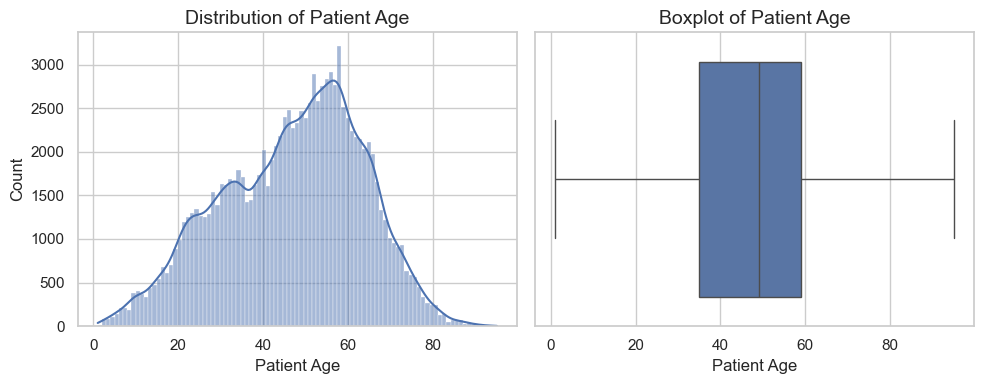

In [34]:
mask, _, _ = detect_outliers_iqr(df, "Patient Age")
df_without_age_outliers = df[~ mask]

univ_num_explore(df_without_age_outliers, "Patient Age")

**Observation**
- ~92% of patients are between 20 and 80
- 16 samples (0.014% of the dataset) contain unrealistic  patient ages (148-155 and 411-414 years), which are likely metadata error.
- 

Value counts for Patient Gender:
Patient Gender
M    63340
F    48780
Name: count, dtype: int64


                Count    Percent
Patient Gender                  
M               63340  56.493043
F               48780  43.506957




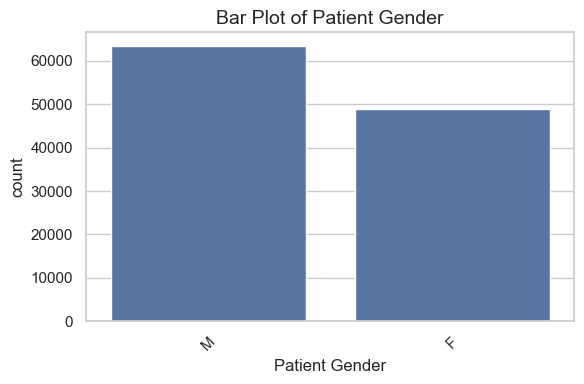

In [35]:
univ_cat_explore(df, "Patient Gender")

Analysis for 'Follow-up #'
----------------------------------------
count    112120.000000
mean          8.573751
std          15.406320
min           0.000000
25%           0.000000
50%           3.000000
75%          10.000000
max         183.000000
Name: Follow-up #, dtype: float64
Missing: 0


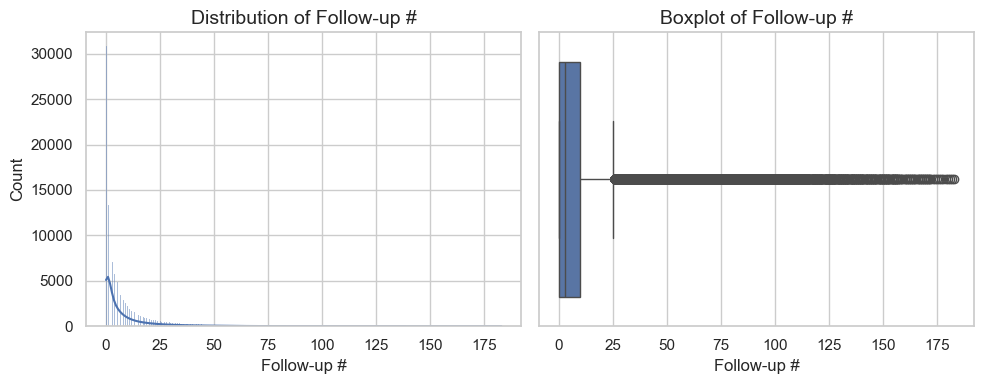

In [69]:
univ_num_explore(df, "Follow-up #")

count    101938.000000
mean          4.665287
std           5.899138
min           0.000000
25%           0.000000
50%           2.000000
75%           7.000000
max          25.000000
Name: Follow-up #, dtype: float64


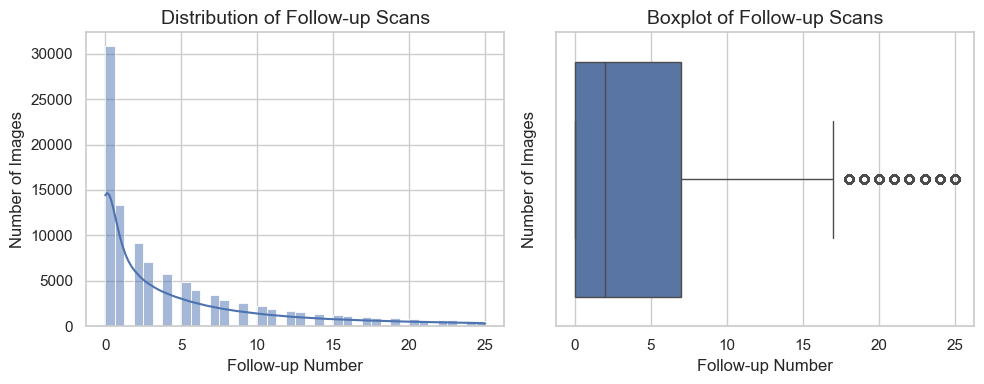

In [37]:
# Handling outliers
mask, _, _ = detect_outliers_iqr(df, "Follow-up #")

print(df[~ mask]["Follow-up #"].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
# Histogram with KDE
sns.histplot(
        data=df[~mask],
        x="Follow-up #",
        bins=40,
        kde=True,
        ax=axes[0]
    )
axes[0].set_title(f"Distribution of Follow-up Scans")
axes[0].set_xlabel("Follow-up Number")
axes[0].set_ylabel("Number of Images")

# Boxplot
sns.boxplot(
    data=df[~ mask],
    x="Follow-up #",
    ax=axes[1]
)
axes[1].set_title(f"Boxplot of Follow-up Scans")
axes[1].set_xlabel("Follow-up Number")
axes[1].set_ylabel("Number of Images")

save_fig("follow_up_scans", "univariate")

plt.tight_layout()
plt.show()

Value counts for View Position:
View Position
PA    67310
AP    44810
Name: count, dtype: int64


               Count    Percent
View Position                  
PA             67310  60.033892
AP             44810  39.966108




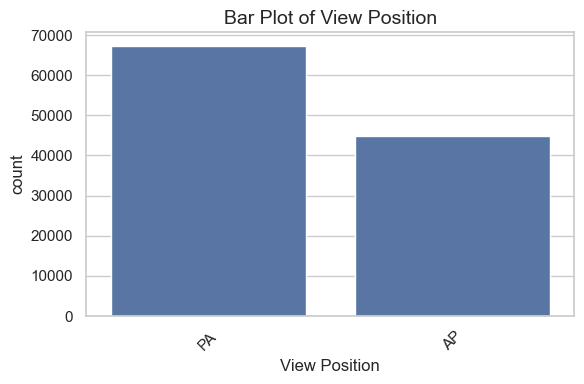

In [38]:
univ_cat_explore(df, "View Position")

# Label Analysis

*What diseases exist in the dataset and how frequent are they?*

In [39]:
# Extract individual diseases
all_labels = df["Finding Labels"].str.split("|")

label_counts = Counter(
    label 
    for labels in all_labels 
    for label in labels
)

label_counts_df = (
    pd.Series(label_counts)
    .sort_values(ascending=False)
)


print("Labels Counts:")
print(label_counts_df)

Labels Counts:
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


In [40]:
label_summary = pd.DataFrame({
    "count": label_counts_df,
    "percent": (label_counts_df / len(df) * 100)
})

label_summary = label_summary.sort_values("count", ascending=False)
label_summary["percent"] = label_summary["percent"].round(2)


label_summary

,count,percent
No Finding,60361,53.84
Infiltration,19894,17.74
Effusion,13317,11.88
Atelectasis,11559,10.31
Nodule,6331,5.65
Mass,5782,5.16
Pneumothorax,5302,4.73
Consolidation,4667,4.16
Pleural_Thickening,3385,3.02
Cardiomegaly,2776,2.48


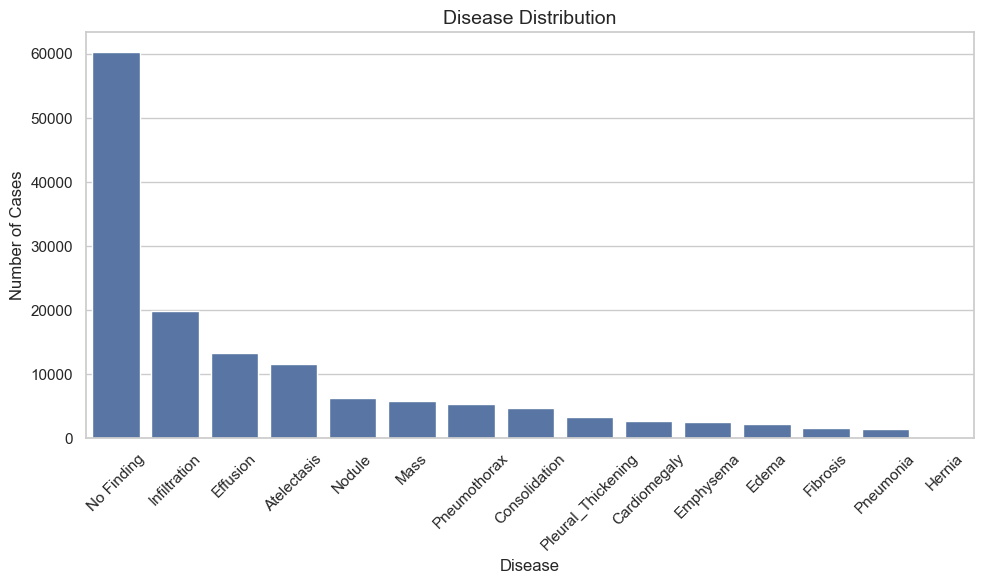

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=label_summary.index,
    y=label_summary["count"]
)

plt.xticks(rotation=45)
plt.title("Disease Distribution")
plt.ylabel("Number of Cases")
plt.xlabel("Disease")
save_fig("disease_distribution", "univariate")
plt.show()

**Observations**
- The dataset contains 14 disease labels plus "No Finding".
- No Finding is the most common label, appearing in 53.8% of images.
- The most frequent diseases are:
    - Infiltration   17.7%
    - Effusion       11.9%
    - Atelectasis    10.3%
- Several diseases appear moderately often:
    - Nodule
    - Mass
    - Pneumothorax
    - Consolidation
- Some diseases are rare:
    - Pneumonia  ≈ 1.3%
    - Hernia     ≈ 0.2%

In [42]:
# Total labels
total_labels = label_counts_df.sum()
print("Total labels counted:", total_labels)

# Average labels per image
print("Avg labels per image:", total_labels / len(df))

Total labels counted: 141537
Avg labels per image: 1.2623706742775598


In [43]:
labels = df["Finding Labels"].str.split("|")

disease_counts = labels.apply(
    lambda x: 0 if x == ["No Finding"] else len(x)
)

disease_counts.describe()

count    112120.000000
mean          0.724010
std           0.963195
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           9.000000
Name: Finding Labels, dtype: float64

In [44]:
total_images = len(disease_counts)

healthy = (disease_counts == 0).sum()
single = (disease_counts == 1).sum()
double = (disease_counts == 2).sum()
multi = (disease_counts >= 3).sum()

summary = pd.DataFrame({
    "category": [
        "Healthy",
        "Single disease",
        "Two diseases",
        "Three or more diseases"
    ],
    "count": [
        healthy,
        single,
        double,
        multi
    ]
})

summary["percent"] = (summary["count"] / total_images * 100).round(2)

summary

,category,count,percent
0,Healthy,60361,53.84
1,Single disease,30963,27.62
2,Two diseases,14306,12.76
3,Three or more diseases,6490,5.79


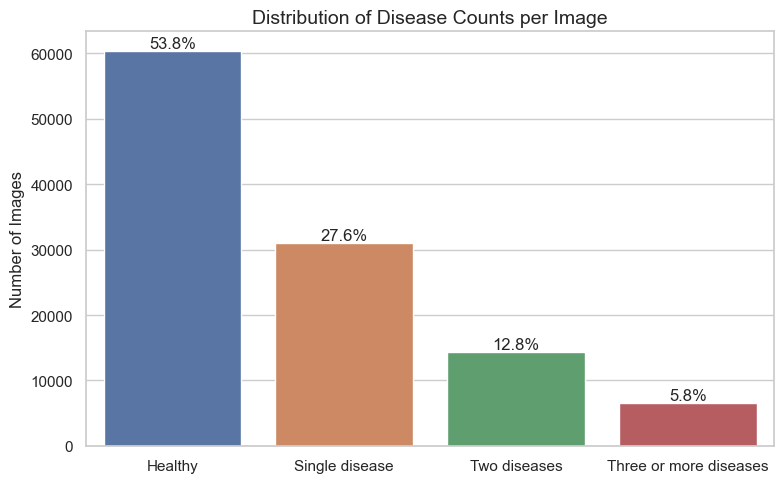

In [45]:
plt.figure()

sns.barplot(
    data=summary,
    x="category",
    y="count",
    hue="category",
    palette="deep",
    legend=False
)

plt.title("Distribution of Disease Counts per Image")
plt.ylabel("Number of Images")
plt.xlabel("")

for index, row in summary.iterrows():
    plt.text(index, row['count'] + 500, f"{row['count']/len(df)*100:.1f}%", ha='center')

save_fig("label_distribution_counts_per_image", "univariate")
plt.tight_layout()
plt.show()

In [46]:
# Patient duplication analysis
patient_counts = df["Patient ID"].value_counts()

patient_counts.describe()

count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: count, dtype: float64

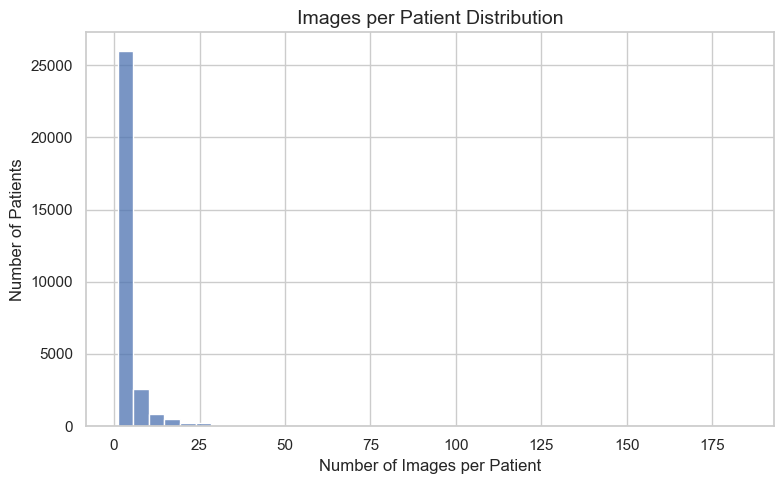

In [47]:
plt.figure()

sns.histplot(
    patient_counts,
    bins=40
)

plt.title("Images per Patient Distribution")
plt.xlabel("Number of Images per Patient")
plt.ylabel("Number of Patients")

plt.tight_layout()
save_fig("images_per_patient_distribution", "univariate")
plt.show()

In [48]:
print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

print("\nHealthy images:", healthy)
print("Images with diseases:", len(df) - healthy)

print("\nAverage images per patient:",
      len(df) / df["Patient ID"].nunique())

Total images: 112120
Unique patients: 30805

Healthy images: 60361
Images with diseases: 51759

Average images per patient: 3.639668884921279


# Bivariate Analysis

In [49]:
age_bins = [0,20,40,60,80,120]

age_labels = [
    "0-20",
    "20-40",
    "40-60",
    "60-80",
    "80+"
]

df["Age Group"] = pd.cut(
    df["Patient Age"],
    bins=age_bins,
    labels=age_labels
)

In [50]:
df["Age Group"].value_counts().sort_index()

Age Group
0-20      7812
20-40    30143
40-60    49502
60-80    23766
80+        881
Name: count, dtype: int64

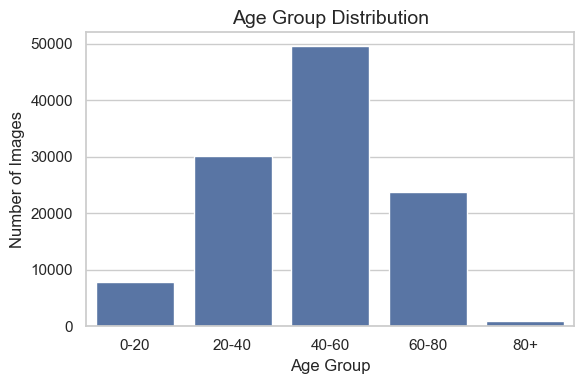

In [51]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Age Group")
plt.title("Age Group Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Age Group")
save_fig("age_group_distribution", "univariate")
plt.show()

In [52]:
target_labels = [
    "Atelectasis",
    "Effusion",
    "Pneumothorax",
    "No Finding"
]

for disease in target_labels:
    df[disease] = df["Finding Labels"].apply(
        lambda x: int(disease in x)
    )

In [53]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,Age Group,Atelectasis,Effusion,Pneumothorax,No Finding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,40-60,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,40-60,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,40-60,0,1,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,80+,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,80+,0,0,0,0


## Age vs Disease

In [54]:
age_disease = df.groupby("Age Group", observed=False)[target_labels].mean()

age_disease

,Atelectasis,Effusion,Pneumothorax,No Finding
Age Group,,,,
0-20,0.065796,0.081413,0.060036,0.586918
20-40,0.076004,0.100687,0.045218,0.577879
40-60,0.112703,0.122904,0.045594,0.533029
60-80,0.128629,0.144029,0.049188,0.487629
80+,0.132804,0.156640,0.048808,0.424518


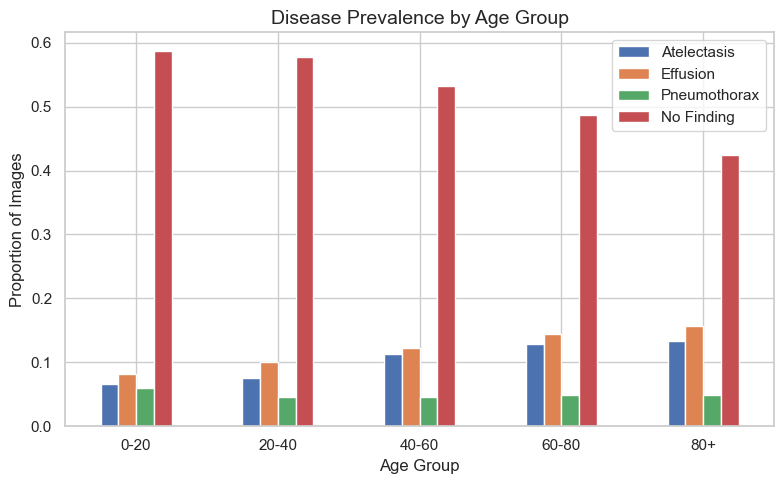

In [55]:
age_disease.plot(kind="bar")

plt.title("Disease Prevalence by Age Group")
plt.ylabel("Proportion of Images")
plt.xlabel("Age Group")

plt.xticks(rotation=0)
save_fig("disease_prevalence_by_age_group_with_nofinding", "bivariate")
plt.show()

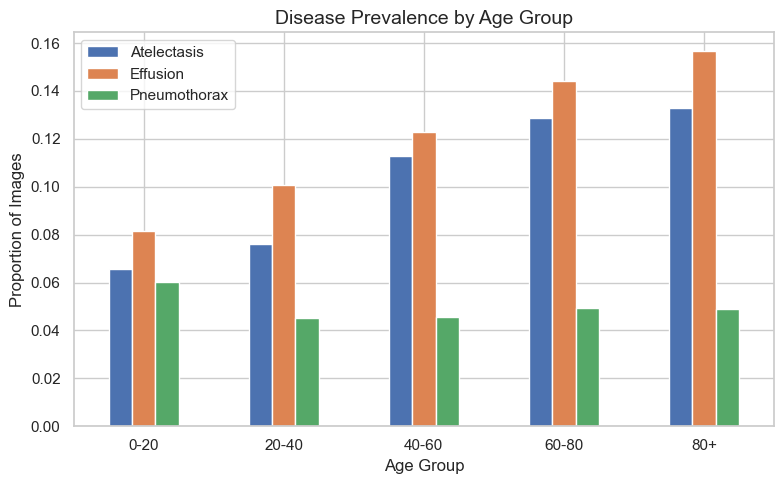

In [56]:
age_disease.drop(['No Finding'], axis=1).plot(kind="bar")

plt.title("Disease Prevalence by Age Group")
plt.ylabel("Proportion of Images")
plt.xlabel("Age Group")

plt.xticks(rotation=0)
save_fig("disease_prevalence_by_age_group_without_nofinding", "bivariate")
plt.show()

## Gender vs Disease

In [57]:
gender_disease = df.groupby("Patient Gender")[target_labels].mean()

gender_disease

,Atelectasis,Effusion,Pneumothorax,No Finding
Patient Gender,,,,
F,0.095387,0.120582,0.052993,0.542005
M,0.109031,0.117382,0.042895,0.535554


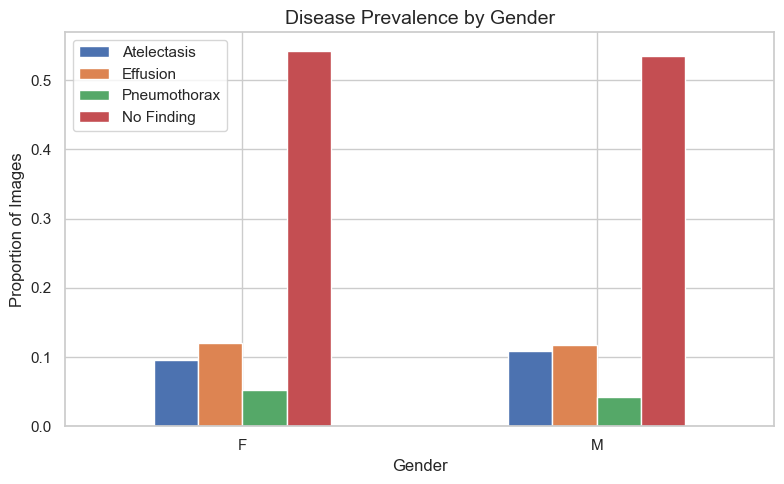

In [58]:
gender_disease.plot(kind="bar")

plt.title("Disease Prevalence by Gender")
plt.ylabel("Proportion of Images")
plt.xlabel("Gender")

plt.xticks(rotation=0)
save_fig("disease_prevalence_by_gender", "bivariate")
plt.show()

In [59]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,Age Group,Atelectasis,Effusion,Pneumothorax,No Finding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,40-60,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,40-60,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,40-60,0,1,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,80+,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,80+,0,0,0,0


## View Position vs Disease

In [60]:
view_disease = df.groupby("View Position")[target_labels].mean()

view_disease

,Atelectasis,Effusion,Pneumothorax,No Finding
View Position,,,,
AP,0.130127,0.150145,0.042290,0.469962
PA,0.085099,0.097890,0.050617,0.583895


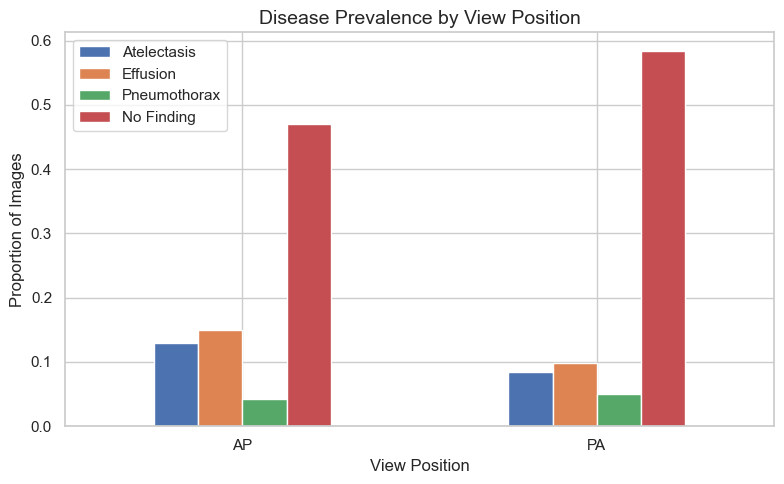

In [61]:
view_disease.plot(kind="bar")

plt.title("Disease Prevalence by View Position")
plt.ylabel("Proportion of Images")
plt.xlabel("View Position")

plt.xticks(rotation=0)
save_fig("disease_prevalence_by_view_position", "bivariate")
plt.show()

# Multivariate Analysis

In [62]:
corr_df = df[
    ["Patient Age"] + target_labels
]

corr_df.corr()

,Patient Age,Atelectasis,Effusion,Pneumothorax,No Finding
Patient Age,1.000000,0.072358,0.062564,-0.005491,-0.072789
Atelectasis,0.072358,1.000000,0.172445,0.031422,-0.366126
Effusion,0.062564,0.172445,1.000000,0.047571,-0.396464
Pneumothorax,-0.005491,0.031422,0.047571,1.000000,-0.240593
No Finding,-0.072789,-0.366126,-0.396464,-0.240593,1.000000


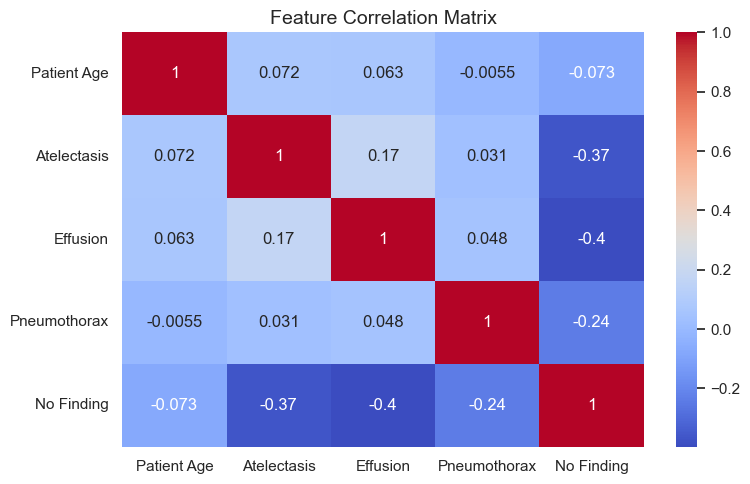

In [63]:
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
save_fig("feature_corr_matrix", "multivariate")
plt.show()

# Visualize Disease X-ray Samples

In [77]:
cache_file = "image_index.pkl"
cache_file = PROJECT_ROOT / "interim" / cache_file
cache_file

WindowsPath('e:/z_grad_proj/chest-xray/chest-pathologies-classification/interim/image_index.pkl')

In [81]:
def build_image_index(data_dir, cache_file="image_index.pkl"):

    data_dir = Path(data_dir)
    cache_file = PROJECT_ROOT / "data/interim" / cache_file

    if cache_file.exists():
        print("Loading cached image index...")
        with open(cache_file, "rb") as f:
            return pickle.load(f)

    print("Building image index...")

    image_index = {}

    for folder in sorted(data_dir.iterdir()):
        if folder.is_dir() and folder.name.startswith("images_"):
            images_path = folder / "images"
            if images_path.exists():
                for file in images_path.iterdir():
                    if file.suffix == ".png":
                        image_index[file.name] = str(file)

    print(f"Indexed {len(image_index)} images")

    with open(cache_file, "wb") as f:
        pickle.dump(image_index, f)

    return image_index

In [82]:
image_index = build_image_index(DATA_DIR)

Building image index...


Indexed 112120 images


In [ ]:
def show_disease_samples(df, disease, image_index, n=9):

    samples = df[df[disease] == 1]["Image Index"].sample(n)
    plt.figure(figsize=(8,8))

    for i, img_name in enumerate(samples):
        img_path = image_index.get(img_name)
        if img_path is None:
            continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(3,3,i+1)
        plt.imshow(img, cmap="gray")

        plt.title(disease)
        plt.axis("off")

    plt.suptitle(f"{disease} Sample X-rays")

    plt.tight_layout()
    plt.show()

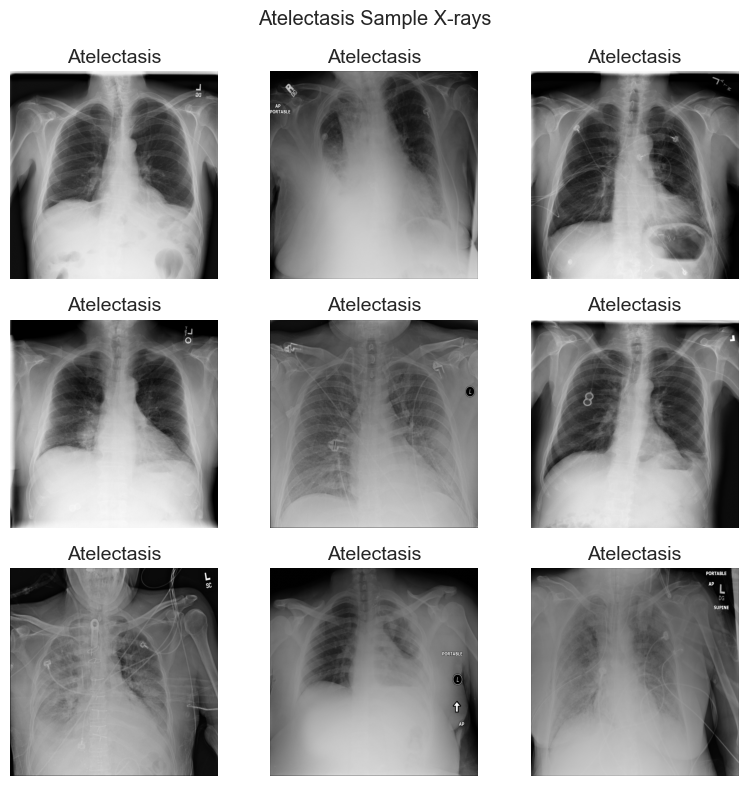

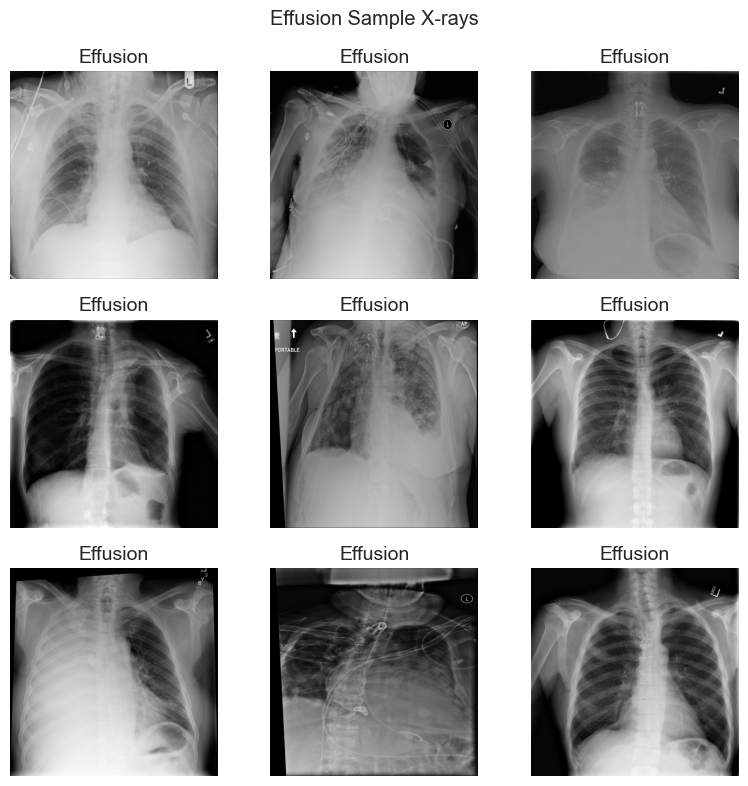

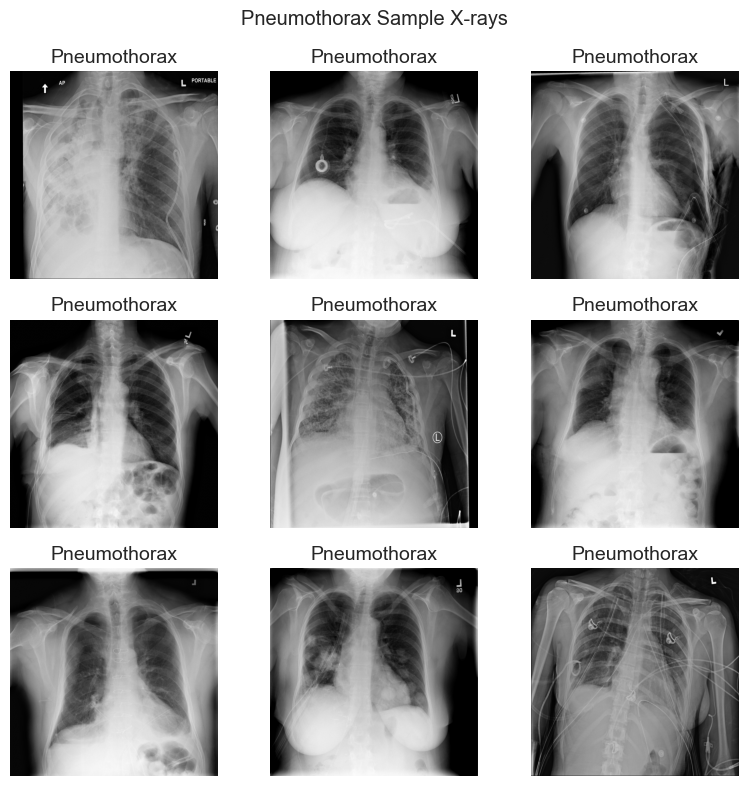

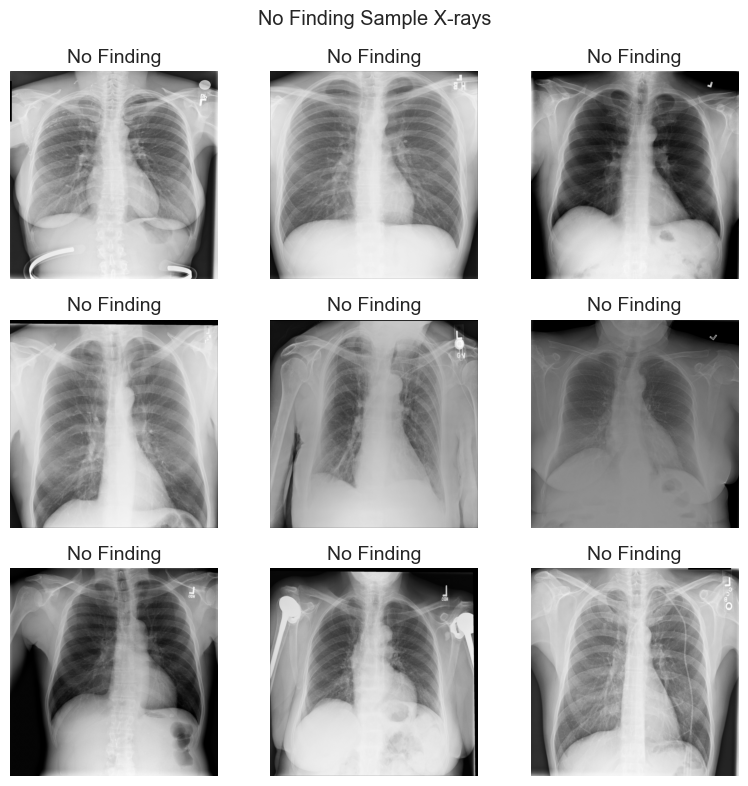

In [67]:
show_disease_samples(df, "Atelectasis", image_index)

show_disease_samples(df, "Effusion", image_index)

show_disease_samples(df, "Pneumothorax", image_index)

show_disease_samples(df, "No Finding", image_index)